# Smart Agriculture & Crop Yield Prediction

This notebook predicts **Yield_tons_per_hectare** from the supplied crop-yield dataset. It is a Python/Jupyter ML workflow, not a frontend or API.

> **Outputs reflect.** the latest successful run. (`Kernel > Restart & Run All`) with `data/crop_yield.csv` present to regenerate results. No metrics are hard-coded in this notebook.

## 1. Setup and dataset loading

The project uses the user-provided `data/crop_yield.csv`. No synthetic data is generated or overwritten. The dataset's provenance (real-world vs. simulated) is not documented in the project, so no claim is made about it.

In [1]:
from pathlib import Path
import sys, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.inspection import permutation_importance
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT)) if str(ROOT) not in sys.path else None
from src.preprocessing import (RAW_FEATURES, TARGET, CATEGORICAL_FEATURES, NUMERICAL_FEATURES, BOOLEAN_FEATURES, clean_agricultural_data)
from src.train_model import train_project
from src.prediction import predict_crop_yield
sns.set_theme(style='whitegrid')
data_path = ROOT / 'data' / 'crop_yield.csv'
if not data_path.exists(): raise FileNotFoundError(f'Missing required dataset: {data_path}')
raw = pd.read_csv(data_path)
print('Dataset shape:', raw.shape)
display(raw.head())

Dataset shape: (1000000, 10)


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


## 2. Inspection and cleaning

Required features are categorical (`Region`, `Soil_Type`, `Crop`, `Weather_Condition`), numeric (`Rainfall_mm`, `Temperature_Celsius`, `Days_to_Harvest`), and Boolean (`Fertilizer_Used`, `Irrigation_Used`). The target is excluded from `X`.

In [2]:
print('Columns:', raw.columns.tolist())
display(raw.dtypes.to_frame('dtype'))
display(raw.isna().sum().to_frame('missing_values'))
print('Duplicate rows:', raw.duplicated().sum())
for col in CATEGORICAL_FEATURES + BOOLEAN_FEATURES:
    print(f'{col}:', raw[col].dropna().unique()[:20])
for col in NUMERICAL_FEATURES + [TARGET]:
    print(col, 'invalid counts:', {'non_numeric': int(pd.to_numeric(raw[col], errors='coerce').isna().sum())})
data = clean_agricultural_data(raw)
print('Rows after duplicate/invalid-row cleaning:', len(data))
display(data.describe(include='all').T)

Columns: ['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']


,dtype
Region,str
Soil_Type,str
Crop,str
Rainfall_mm,float64
Temperature_Celsius,float64
Fertilizer_Used,bool
Irrigation_Used,bool
Weather_Condition,str
Days_to_Harvest,int64
Yield_tons_per_hectare,float64


,missing_values
Region,0
Soil_Type,0
Crop,0
Rainfall_mm,0
Temperature_Celsius,0
Fertilizer_Used,0
Irrigation_Used,0
Weather_Condition,0
Days_to_Harvest,0
Yield_tons_per_hectare,0


Duplicate rows: 0
Region: <StringArray>
['West', 'South', 'North', 'East']
Length: 4, dtype: str
Soil_Type: <StringArray>
['Sandy', 'Clay', 'Loam', 'Silt', 'Peaty', 'Chalky']
Length: 6, dtype: str
Crop: <StringArray>
['Cotton', 'Rice', 'Barley', 'Soybean', 'Wheat', 'Maize']
Length: 6, dtype: str
Weather_Condition: <StringArray>
['Cloudy', 'Rainy', 'Sunny']
Length: 3, dtype: str
Fertilizer_Used: [False  True]
Irrigation_Used: [ True False]
Rainfall_mm invalid counts: {'non_numeric': 0}


Temperature_Celsius invalid counts: {'non_numeric': 0}
Days_to_Harvest invalid counts: {'non_numeric': 0}
Yield_tons_per_hectare invalid counts: {'non_numeric': 0}


Rows after duplicate/invalid-row cleaning: 999769


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Region,999769,4,North,250112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Soil_Type,999769,6,Sandy,167081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,999769,6,Maize,166785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rainfall_mm,999769.0,NaN,NaN,NaN,550.077823,259.804329,100.000896,325.062906,550.229205,774.797949,999.998098
Temperature_Celsius,999769.0,NaN,NaN,NaN,27.506079,7.220488,15.000034,21.256078,27.509509,33.754459,39.999997
Fertilizer_Used,999769.0,NaN,NaN,NaN,0.500056,0.5,0.0,0.0,1.0,1.0,1.0
Irrigation_Used,999769.0,NaN,NaN,NaN,0.499606,0.5,0.0,0.0,0.0,1.0,1.0
Weather_Condition,999769,3,Sunny,333701,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days_to_Harvest,999769.0,NaN,NaN,NaN,104.495141,25.953328,60.0,82.0,104.0,127.0,149.0
Yield_tons_per_hectare,999769.0,NaN,NaN,NaN,4.650592,1.695166,0.000411,3.418669,4.652333,5.879576,9.963372


## 3. Outlier review and exploratory data analysis

IQR flags are statistical prompts for review, not automatic deletion. Cleaning only removes duplicates and clearly invalid values (negative rainfall/yield, non-positive days to harvest, or physically implausible temperature).

,IQR_flag_count
Rainfall_mm,0
Temperature_Celsius,0
Days_to_Harvest,0
Yield_tons_per_hectare,28


Text(0.5, 1.0, 'Numeric correlation heatmap')

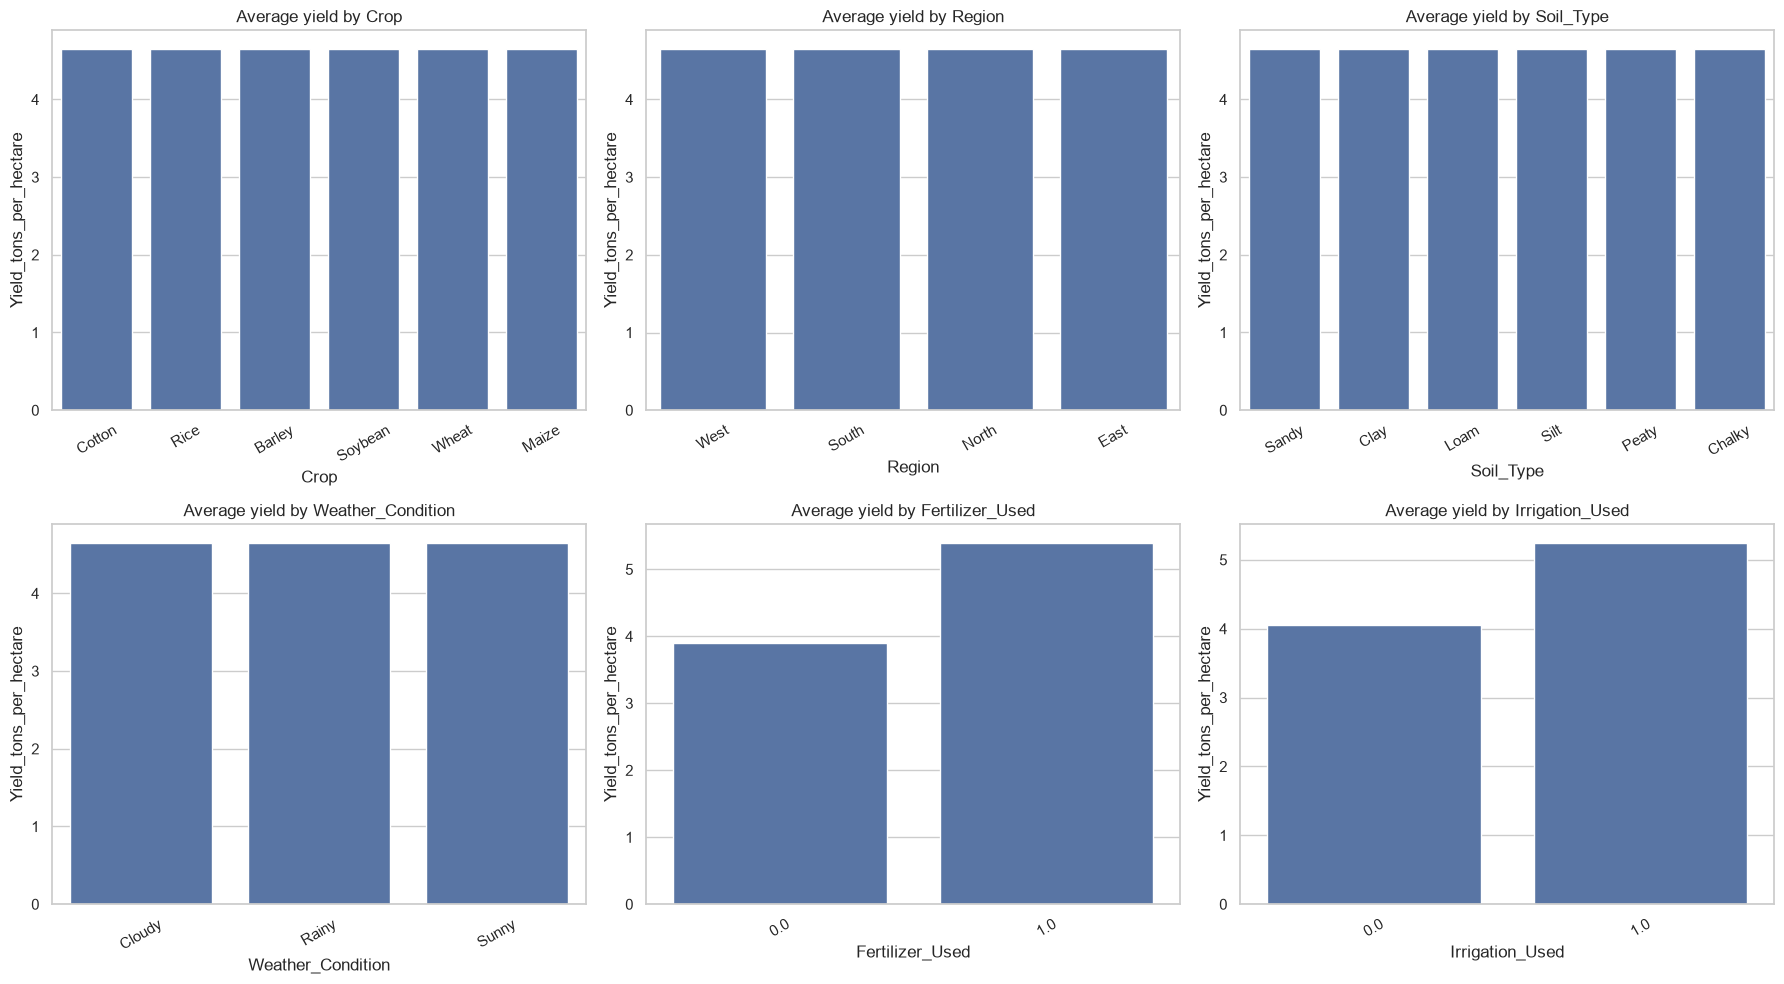

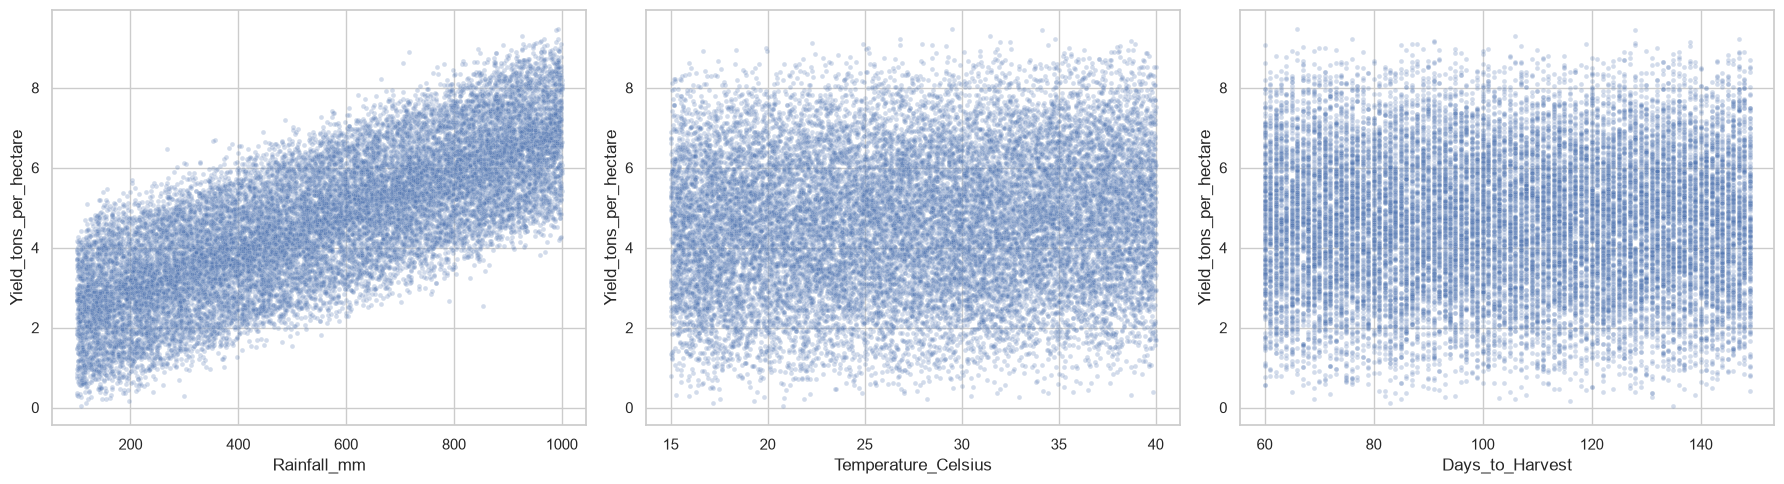

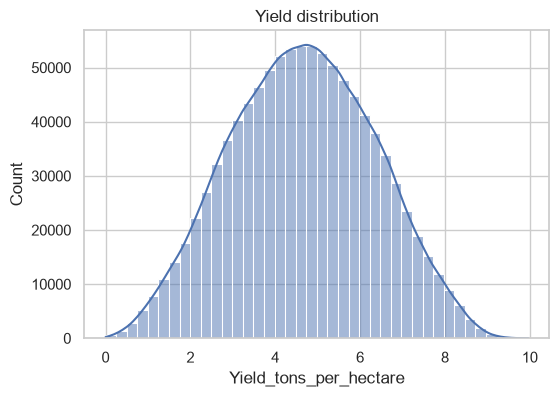

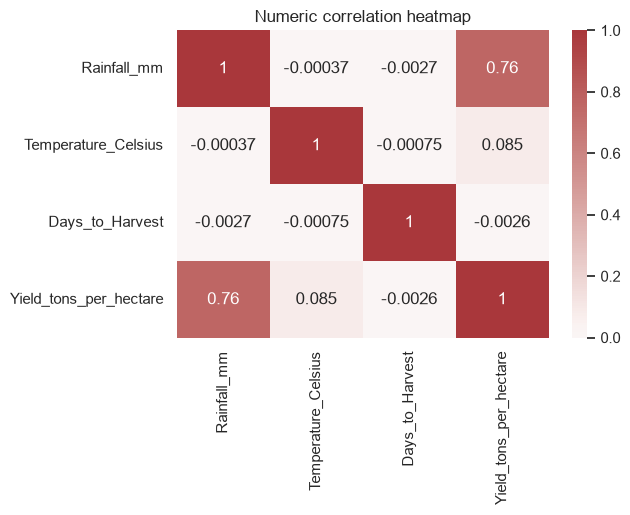

In [3]:
q1, q3 = data[NUMERICAL_FEATURES + [TARGET]].quantile(.25), data[NUMERICAL_FEATURES + [TARGET]].quantile(.75)
iqr = q3-q1
display((((data[NUMERICAL_FEATURES + [TARGET]] < q1-1.5*iqr) | (data[NUMERICAL_FEATURES + [TARGET]] > q3+1.5*iqr)).sum()).to_frame('IQR_flag_count'))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), ['Crop','Region','Soil_Type','Weather_Condition','Fertilizer_Used','Irrigation_Used']):
    sns.barplot(data=data, x=col, y=TARGET, errorbar=None, ax=ax)
    ax.set_title(f'Average yield by {col}'); ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, NUMERICAL_FEATURES): sns.scatterplot(data=data.sample(min(20000,len(data)), random_state=42), x=col, y=TARGET, alpha=.25, s=12, ax=ax)
plt.tight_layout()
plt.figure(figsize=(6,4)); sns.histplot(data[TARGET], bins=40, kde=True); plt.title('Yield distribution')
plt.figure(figsize=(6,4)); sns.heatmap(data[NUMERICAL_FEATURES + [TARGET]].corr(), annot=True, cmap='vlag', center=0); plt.title('Numeric correlation heatmap')

## 4. Leak-safe training, comparison, and tuning

`train_project` runs the following workflow; the test set is used only in the final step:

1. Clean the data, then split rows **80/20** (`random_state=42`) before fitting any preprocessing.
2. Run **5-fold `KFold` CV on training rows only** for four baseline pipelines: Linear Regression, Decision Tree, Random Forest, Gradient Boosting. Metrics: `CV_MAE`, `CV_RMSE`, `CV_R2`.
3. Select the baseline with the lowest **`CV_RMSE`**.
4. Tune **only the selected model** with 5-fold `RandomizedSearchCV` (RMSE scoring) on training rows.
5. **Refit** the tuned pipeline on all training rows.
6. Evaluate the 20% test set **exactly once** (`MAE`, `MSE`, `RMSE`, `R2`).

Every pipeline normalizes Boolean fields, creates the explainable `Rainfall_x_Irrigation` interaction, imputes values, encodes categories with unknown-category safety, and fits the estimator. If the training partition has more than 100,000 rows, CV and tuning use a fixed, reproducible 100,000-row random subset of the training partition for runtime practicality; the final refit uses all training rows. Training the full pipeline on a large CSV can take a long time.

In [4]:
results = train_project(ROOT, tune=True)
comparison = results['comparison']
display(comparison.style.format({'CV_MAE':'{:.4f}', 'CV_RMSE':'{:.4f}', 'CV_R2':'{:.4f}'}))
print('Selected model (lowest CV_RMSE):', results['candidate_name'])
if results['tuning'] is not None:
    print('Best tuning parameters:', results['tuning'].best_params_)
    print('Best tuning CV RMSE (training data only):', round(-results['tuning'].best_score_, 4))
print('Final test metrics (single evaluation):', {k: round(v, 4) for k, v in results['final_metrics'].items()})
print('MAE: average absolute error. MSE: squared error. RMSE: error in tons/hectare. R²: explained variance, not accuracy.')

,Model,CV_MAE,CV_RMSE,CV_R2
0,Linear Regression,0.3986,0.4989,0.9130
1,Random Forest,0.4130,0.5171,0.9065
2,Gradient Boosting,0.4189,0.5250,0.9037
3,Decision Tree,0.5068,0.6326,0.8601


Selected model (lowest CV_RMSE): Linear Regression
Best tuning parameters: {'model__positive': True, 'model__fit_intercept': True}
Best tuning CV RMSE (training data only): 0.4989
Final test metrics (single evaluation): {'MAE': 0.3983, 'MSE': 0.2493, 'RMSE': 0.4993, 'R2': 0.9132}
MAE: average absolute error. MSE: squared error. RMSE: error in tons/hectare. R²: explained variance, not accuracy.


## 5. Final evaluation and interpretability

The left plot compares baseline models by training-only `CV_RMSE`. The actual-vs-predicted and residual plots describe the already-selected final model on the test set; they are not used to change the model. Permutation importance reports influence on predictions, not causal effects.

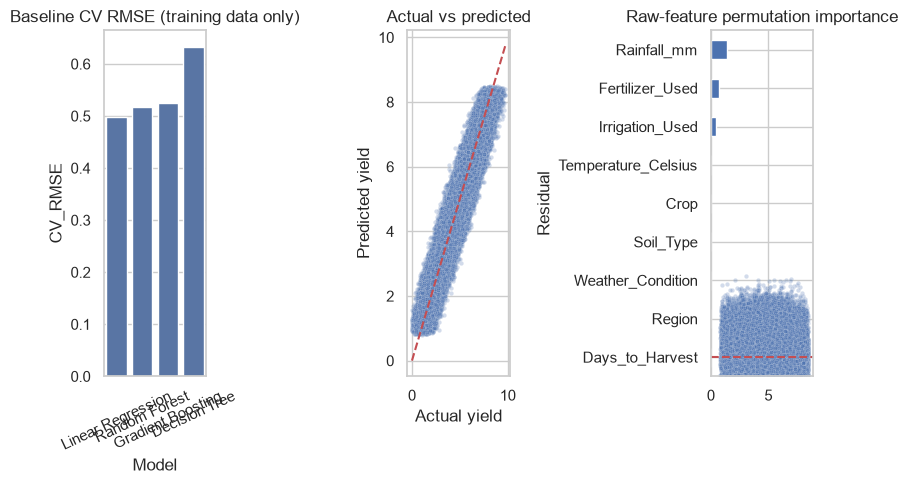

In [5]:
final_model, y_test, pred = results['final_model'], results['y_test'], results['predictions']
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.barplot(data=comparison, x='Model', y='CV_RMSE', ax=axes[0]); axes[0].set_title('Baseline CV RMSE (training data only)'); axes[0].tick_params(axis='x', rotation=25)
sns.scatterplot(x=y_test, y=pred, alpha=.25, s=10, ax=axes[1]); lim=[min(y_test.min(),pred.min()),max(y_test.max(),pred.max())]; axes[1].plot(lim,lim,'r--'); axes[1].set(xlabel='Actual yield',ylabel='Predicted yield',title='Actual vs predicted')
sns.scatterplot(x=pred, y=y_test-pred, alpha=.25, s=10, ax=axes[2]); axes[2].axhline(0,color='r',linestyle='--'); axes[2].set(xlabel='Predicted yield',ylabel='Residual',title='Residual plot'); plt.tight_layout()
perm = permutation_importance(final_model, results['X_test'], y_test, n_repeats=5, random_state=42, n_jobs=-1, scoring='neg_root_mean_squared_error')
pd.Series(perm.importances_mean, index=RAW_FEATURES).sort_values().plot.barh(figsize=(8,5), title='Raw-feature permutation importance'); plt.tight_layout()

## 6. Save, reload, and predict

The model artifact contains feature transformation, preprocessing, and estimator. The function uses the actual source schema and validates inputs.

In [6]:
loaded_model = joblib.load(results['model_path'])
example = raw.iloc[0]
prediction = predict_crop_yield(loaded_model, region=example['Region'], soil_type=example['Soil_Type'], crop=example['Crop'], rainfall_mm=example['Rainfall_mm'], temperature_celsius=example['Temperature_Celsius'], fertilizer_used=bool(example['Fertilizer_Used']), irrigation_used=bool(example['Irrigation_Used']), weather_condition=example['Weather_Condition'], days_to_harvest=example['Days_to_Harvest'])
print(f'Prediction: {prediction:.4f} tons/hectare')
print('Saved/reloaded pipeline:', results['model_path'])

Prediction: 6.2386 tons/hectare
Saved/reloaded pipeline: D:\Codes\DATA_Science_Intership\ML_project\Smart_Agriculture_and_Crop_Yield\models\crop_yield_prediction_model.pkl


## Conclusion and limitations

The final model is chosen by training-only 5-fold CV RMSE rather than a hard-coded choice, tuned only on training data, and scored once on the held-out test set. Results describe patterns in this dataset and should not be treated as proof that a feature causes yield. Missing agricultural context, time shifts, or regional generalization may limit performance outside this dataset.